IMPORTS

In [7]:
import sys
import os

# Add project root to Python path (CRITICAL FIX)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Now imports will work
from src.data_loader import load_data
from src.preprocessing import remove_duplicates, handle_missing_values, convert_datetime
from src.feature_engineering import create_time_features

print("✅ Imports successful! Project root:", project_root)

✅ Imports successful! Project root: /home/dag-dagne/Desktop/10 Acadamy/week 5/fraud-detection-interim2


In [8]:
# Load datasets
fraud_df = load_data("../data/raw/Fraud_Data.csv")
credit_df = load_data("../data/raw/creditcard.csv")
ip_df = load_data("../data/raw/IpAddress_to_Country.csv")

print("Fraud shape:", fraud_df.shape)
print("IP shape:", ip_df.shape)

Loaded: ../data/raw/Fraud_Data.csv | Shape: (151112, 11)
Loaded: ../data/raw/creditcard.csv | Shape: (284807, 31)
Loaded: ../data/raw/IpAddress_to_Country.csv | Shape: (138846, 3)
Fraud shape: (151112, 11)
IP shape: (138846, 3)


In [9]:
fraud_df = remove_duplicates(fraud_df)
fraud_df = handle_missing_values(fraud_df)
fraud_df = convert_datetime(fraud_df, ["signup_time", "purchase_time"])

In [11]:
fraud_df = create_time_features(fraud_df)


# Drop high-cardinality columns BEFORE encoding
drop_cols = ['user_id', 'device_id', 'ip_address', 'ip_int']
fraud_df = fraud_df.drop(columns=drop_cols, errors='ignore')

print("Remaining columns:", fraud_df.columns.tolist())

Remaining columns: ['signup_time', 'purchase_time', 'purchase_value', 'source', 'browser', 'sex', 'age', 'class', 'hour_of_day', 'day_of_week', 'time_since_signup']


In [12]:
y = fraud_df["class"].copy()
X = fraud_df.drop(columns=["class"]).copy()

In [13]:
for col in X.select_dtypes(include=['datetime64']).columns:
    X[col] = X[col].astype('int64') // 10**9

In [15]:
# CELL 7 — ENCODE CATEGORICAL (Safe version - NO 'country')
cat_cols = ['source', 'browser', 'sex']   

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("✅ Final shape after encoding:", X.shape)
print("Memory usage (MB):", round(X.memory_usage(deep=True).sum() / (1024**2), 2))
print("Sample columns:", X.columns.tolist()[:10])  # Preview

✅ Final shape after encoding: (151112, 14)
Memory usage (MB): 7.93
Sample columns: ['signup_time', 'purchase_time', 'purchase_value', 'age', 'hour_of_day', 'day_of_week', 'time_since_signup', 'source_Direct', 'source_SEO', 'browser_FireFox']


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)

Train shape: (120889, 14)


In [17]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

Before SMOTE: {0: 109568, 1: 11321}
After SMOTE: {0: 109568, 1: 109568}


Fraud distribution:
 class
0    0.906354
1    0.093646
Name: proportion, dtype: float64


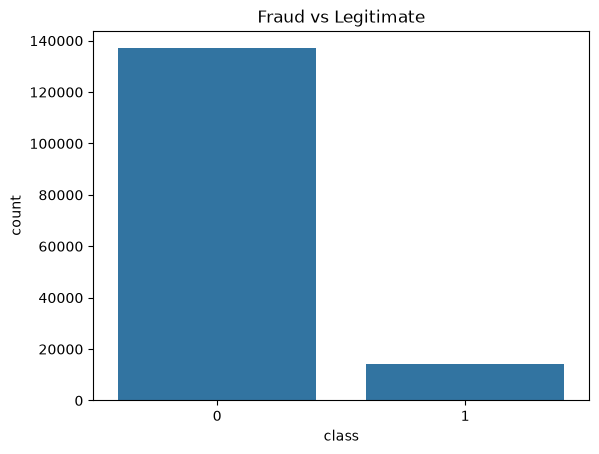

In [18]:
print("Fraud distribution:\n", fraud_df['class'].value_counts(normalize=True))
sns.countplot(x='class', data=fraud_df)
plt.title("Fraud vs Legitimate")
plt.show()

In [19]:
import joblib
import os
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import (
    classification_report, 
    roc_auc_score, 
    average_precision_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Modeling libraries imported successfully")

✅ Modeling libraries imported successfully


/home/dag-dagne/Desktop/10 Acadamy/week 5/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


=== Logistic Regression Performance ===
AUC-PR (Primary Metric): 0.5466
ROC-AUC: 0.7589
F1-Score: 0.2672

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.64      0.76     27393
           1       0.17      0.70      0.27      2830

    accuracy                           0.64     30223
   macro avg       0.56      0.67      0.52     30223
weighted avg       0.88      0.64      0.72     30223



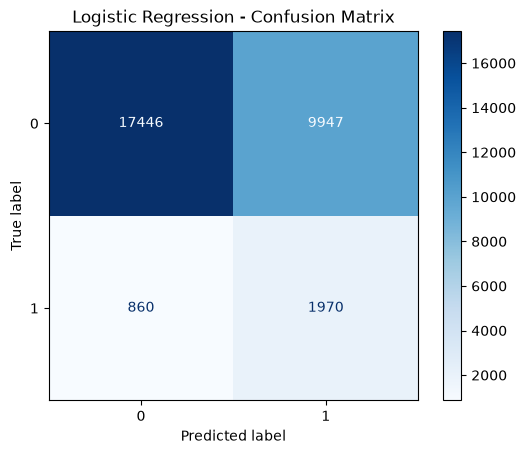

In [20]:
# Train Logistic Regression on resampled data
lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train_res, y_train_res)

# Predict on original (unseen) test set
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Evaluation
print("=== Logistic Regression Performance ===")
print("AUC-PR (Primary Metric):", round(average_precision_score(y_test, y_pred_proba_lr), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba_lr), 4))
print("F1-Score:", round(f1_score(y_test, y_pred_lr), 4))

print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr).plot(cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

=== XGBoost Performance ===
AUC-PR (Primary Metric): 0.6188
ROC-AUC: 0.7649
F1-Score: 0.2216

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.45      0.61     27393
           1       0.13      0.79      0.22      2830

    accuracy                           0.48     30223
   macro avg       0.54      0.62      0.42     30223
weighted avg       0.88      0.48      0.58     30223



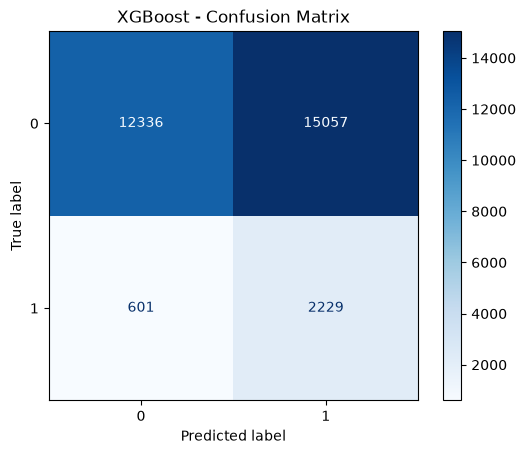

In [21]:
# Calculate scale_pos_weight to handle imbalance
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='aucpr',
    n_jobs=-1
)

xgb_model.fit(X_train_res, y_train_res)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("=== XGBoost Performance ===")
print("AUC-PR (Primary Metric):", round(average_precision_score(y_test, y_pred_proba_xgb), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba_xgb), 4))
print("F1-Score:", round(f1_score(y_test, y_pred_xgb), 4))

print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm_xgb).plot(cmap='Blues')
plt.title("XGBoost - Confusion Matrix")
plt.show()

In [22]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "AUC-PR": [
        average_precision_score(y_test, y_pred_proba_lr),
        average_precision_score(y_test, y_pred_proba_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_xgb)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_xgb)
    ]
})

print("=== Model Comparison ===")
print(comparison.round(4))

=== Model Comparison ===
                 Model  AUC-PR  ROC-AUC  F1-Score
0  Logistic Regression  0.5466   0.7589    0.2672
1              XGBoost  0.6188   0.7649    0.2216


In [23]:
os.makedirs("../models", exist_ok=True)

joblib.dump(lr_model, "../models/logistic_regression.pkl")
joblib.dump(xgb_model, "../models/xgboost_model.pkl")

print("✅ Models saved successfully in ../models/")

✅ Models saved successfully in ../models/
